In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from base64 import b64decode
from IPython.display import display, Javascript, Video
from google.colab.output import eval_js
from google.colab import files

In [2]:
def gamma_correction(img, gamma=0.5):
  if gamma <= 0:
    raise ValueError('Gamma Must Be Greater Than Zero')

  table = np.array([
      ((value / 255.0) ** gamma) * 255
      for value in np.arange(256)
  ]).astype('uint8')

  return cv2.LUT(img, table)

In [15]:
def record_webcam(seconds=8, filename='webcam_input.webm'):
    display(Javascript('''
    async function recordWebcam(seconds) {
      const stream = await navigator.mediaDevices.getUserMedia({
        video: true,
        audio: false
      });

      const recorder = new MediaRecorder(stream, {mimeType: 'video/webm'});
      const chunks = [];
      recorder.ondataavailable = event => {
        if (event.data.size > 0) chunks.push(event.data);
      };

      recorder.start();
      await new Promise(resolve => setTimeout(resolve, seconds * 1000));

      const stopped = new Promise(resolve => recorder.onstop = resolve);
      recorder.stop();
      await stopped;
      stream.getTracks().forEach(track => track.stop());

      const blob = new Blob(chunks, {type: 'video/webm'});
      return await new Promise(resolve => {
        const reader = new FileReader();
        reader.onloadend = () => resolve(reader.result);
        reader.readAsDataURL(blob);
      });
    }
    '''))

    data_url = eval_js(f'recordWebcam({int(seconds)})')
    video_bytes = b64decode(data_url.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(video_bytes)
    return filename

webcam_path = record_webcam(seconds=8)

print('Saved Webcam Video:', webcam_path)

<IPython.core.display.Javascript object>

Saved Webcam Video: webcam_input.webm


In [9]:
gamma = 0.5
capture = cv2.VideoCapture(webcam_path)

if not capture.isOpened():
  raise ValueError('Could Not Open Webcam Video.')

fps = capture.get(cv2.CAP_PROP_FPS)
if fps <= 0:
  fps = 20.0
width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

original_path = '/content/webcam_original.mp4'
corrected_path = '/content/webcam_gamma_corrected.mp4'
comparison_path = '/content/webcam_original_vs_gamma.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

original_writer = cv2.VideoWriter(original_path, fourcc, fps, (width, height), True)
corrected_writer = cv2.VideoWriter(corrected_path, fourcc, fps, (width, height), True)
comparison_writer = cv2.VideoWriter(comparison_path, fourcc, fps, (width * 2, height), True)

sample_original = None
sample_corrected = None
frame_count = 0

while True:
  ret, frame = capture.read()

  if not ret:
    break

  corrected = gamma_correction(frame, gamma)
  original_writer.write(frame)
  corrected_writer.write(corrected)
  comparison_writer.write(np.hstack((frame, corrected)))

  if sample_original is None:
    sample_original = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    sample_corrected = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

  frame_count += 1

original_writer.release()
corrected_writer.release()
comparison_writer.release()
capture.release()

print('Frames Processed:', frame_count)
print('Gamma:', gamma)

Frames Processed: 250
Gamma: 0.5


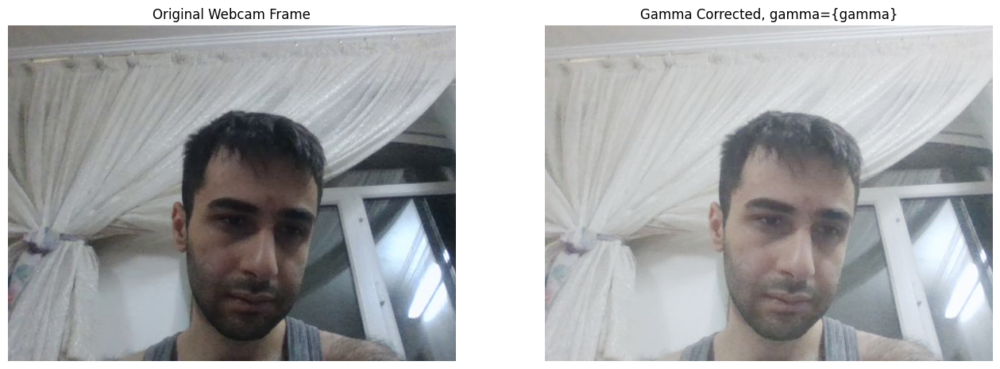

In [10]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.imshow(sample_original)
plt.title('Original Webcam Frame')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_corrected)
plt.title('Gamma Corrected, gamma={gamma}')
plt.axis('off')

plt.show()

In [12]:
display(Video(original_path, embed=True, width=650))
display(Video(corrected_path, embed=True, width=650))
display(Video(comparison_path, embed=True, width=1000))

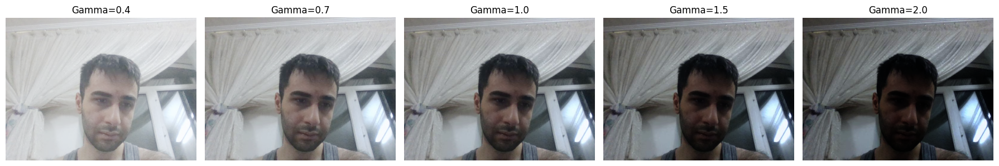

In [13]:
gamma_values = [0.4, 0.7, 1.0, 1.5, 2.0]

plt.figure(figsize=(18, 8))
for i, value in enumerate(gamma_values, start=1):
  adjusted = gamma_correction(cv2.cvtColor(sample_original, cv2.COLOR_RGB2BGR), value)
  adjusted_rgb = cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB)
  plt.subplot(1, len(gamma_values), i)
  plt.imshow(adjusted_rgb)
  plt.title(f'Gamma={value}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [14]:
for output_path in [original_path, corrected_path, comparison_path]:
  files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>